In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
current_folder = Path.cwd()

if current_folder.name == "results":
    project_folder = current_folder.parent
elif (current_folder / "results").exists() and (current_folder / "data").exists():
    project_folder = current_folder
else:
    raise FileNotFoundError(
        "The project folder could not be found automatically. "
        "Set project_folder manually in this cell."
    )

results_folder = project_folder / "results"
data_folder = project_folder / "data"

print("Project folder:", project_folder)
print("Results folder:", results_folder)
print("Data folder:", data_folder)


Project folder: c:\Users\Alex\MasterThesis
Results folder: c:\Users\Alex\MasterThesis\results
Data folder: c:\Users\Alex\MasterThesis\data


In [6]:
all_summary_files = sorted(
    results_folder.rglob("summary_runs_*.csv")
)

all_rerun_files = sorted(
    results_folder.rglob("rerun_summary_runs_*.csv")
)

# Keep only the Dutch case-study files.
# Proof-of-concept and other summary files are ignored.
valid_original_names = re.compile(
    r"summary_runs_(cs2_)?nl34_(z1|z3)_sigma(0|25|50|75|100)\.csv"
)

valid_rerun_names = re.compile(
    r"rerun_summary_runs_(cs2_)?nl34_(z1|z3)_sigma(0|25|50|75|100)\.csv"
)

original_files = [
    file for file in all_summary_files
    if valid_original_names.fullmatch(file.name)
]

rerun_files = [
    file for file in all_rerun_files
    if valid_rerun_names.fullmatch(file.name)
]

ignored_files = [
    file for file in all_summary_files
    if not valid_original_names.fullmatch(file.name)
    and not file.name.startswith("rerun_")
]

print("Original case-study files found:", len(original_files))
for file in original_files:
    print(" ", file.relative_to(results_folder))

print("\nRerun case-study files found:", len(rerun_files))
for file in rerun_files:
    print(" ", file.relative_to(results_folder))

print("\nOther summary files ignored:", len(ignored_files))
for file in ignored_files:
    print(" ", file.relative_to(results_folder))

if len(original_files) == 0:
    raise FileNotFoundError(
        "No Dutch case-study summary files were found inside the results folder."
    )

Original case-study files found: 12
  final_cs2_nl34_z1_sigma0\summary_runs_cs2_nl34_z1_sigma0.csv
  final_cs2_nl34_z3_sigma0\summary_runs_cs2_nl34_z3_sigma0.csv
  final_cs2_nl34_z3_sigma100\summary_runs_cs2_nl34_z3_sigma100.csv
  final_cs2_nl34_z3_sigma25\summary_runs_cs2_nl34_z3_sigma25.csv
  final_cs2_nl34_z3_sigma50\summary_runs_cs2_nl34_z3_sigma50.csv
  final_cs2_nl34_z3_sigma75\summary_runs_cs2_nl34_z3_sigma75.csv
  final_nl34_z1_sigma0\summary_runs_nl34_z1_sigma0.csv
  final_nl34_z3_sigma0\summary_runs_nl34_z3_sigma0.csv
  final_nl34_z3_sigma100\summary_runs_nl34_z3_sigma100.csv
  final_nl34_z3_sigma25\summary_runs_nl34_z3_sigma25.csv
  final_nl34_z3_sigma50\summary_runs_nl34_z3_sigma50.csv
  final_nl34_z3_sigma75\summary_runs_nl34_z3_sigma75.csv

Rerun case-study files found: 6
  reruns_cs2_nl34_z1_sigma0\rerun_summary_runs_cs2_nl34_z1_sigma0.csv
  reruns_cs2_nl34_z3_sigma0\rerun_summary_runs_cs2_nl34_z3_sigma0.csv
  reruns_cs2_nl34_z3_sigma100\rerun_summary_runs_cs2_nl34_z3_si

In [7]:
def read_file_name(file_path):
    file_name = Path(file_path).name

    clean_name = file_name.replace("rerun_", "")
    clean_name = clean_name.replace("summary_runs_", "")
    clean_name = clean_name.replace(".csv", "")

    case_study = 2 if clean_name.startswith("cs2_") else 1

    if case_study == 2:
        clean_name = clean_name.replace("cs2_", "", 1)

    match = re.fullmatch(r"nl34_(z\d)_sigma(\d+)", clean_name)

    if match is None:
        raise ValueError(f"Unexpected file name: {file_name}")

    design = match.group(1)
    sigma = int(match.group(2)) / 100

    return case_study, design, sigma


def read_summary_files(file_list, source_name):
    all_data = []

    for file_path in file_list:
        case_study, design, sigma = read_file_name(file_path)

        data = pd.read_csv(file_path)
        data["case_study"] = case_study
        data["design"] = design
        data["sigma"] = sigma
        data["source"] = source_name
        data["source_file"] = str(file_path.relative_to(results_folder))

        all_data.append(data)

    if len(all_data) == 0:
        return pd.DataFrame()

    return pd.concat(all_data, ignore_index=True)


original_runs = read_summary_files(original_files, "original")
rerun_runs = read_summary_files(rerun_files, "rerun")

print("Original rows:", len(original_runs))
print("Rerun rows:", len(rerun_runs))


Original rows: 960
Rerun rows: 12


In [8]:
merge_columns = ["case_study", "design", "sigma", "run_id"]

if len(rerun_runs) > 0:
    rerun_keys = rerun_runs[merge_columns].drop_duplicates()

    original_with_flag = original_runs.merge(
        rerun_keys.assign(has_rerun=True),
        on=merge_columns,
        how="left"
    )

    original_without_rerun = original_with_flag[
        original_with_flag["has_rerun"].isna()
    ].drop(columns="has_rerun")

    final_runs = pd.concat(
        [original_without_rerun, rerun_runs],
        ignore_index=True
    )
else:
    final_runs = original_runs.copy()

duplicate_rows = final_runs.duplicated(merge_columns).sum()

print("Final rows:", len(final_runs))
print("Duplicate final rows:", duplicate_rows)

if duplicate_rows > 0:
    raise ValueError("Duplicate runs found after merging.")


Final rows: 960
Duplicate final rows: 0


In [9]:
ptdf_file = data_folder / "nl34_ptdf_matrix.csv"

if not ptdf_file.exists():
    raise FileNotFoundError(f"PTDF file not found: {ptdf_file}")

ptdf = pd.read_csv(ptdf_file)

print("PTDF file:", ptdf_file)
print("PTDF rows:", len(ptdf))


PTDF file: c:\Users\Alex\MasterThesis\data\nl34_ptdf_matrix.csv
PTDF rows: 40


In [10]:
bus_columns = [column for column in ptdf.columns if column != "Line"]

mapping_rows = []

for row_number, row in ptdf.reset_index(drop=True).iterrows():
    values = row[bus_columns].to_numpy(dtype=float)

    non_zero_values = int(np.sum(np.abs(values) > 1e-9))
    density = non_zero_values / len(bus_columns)
    line_index = int(row["Line"])

    mapping_rows.append({
        "run_id": 2 * row_number + 1,
        "line_idx": line_index,
        "direction": "positive",
        "ptdf_nonzero": non_zero_values,
        "ptdf_density": density
    })

    mapping_rows.append({
        "run_id": 2 * row_number + 2,
        "line_idx": line_index,
        "direction": "negative",
        "ptdf_nonzero": non_zero_values,
        "ptdf_density": density
    })

run_mapping = pd.DataFrame(mapping_rows)

final_runs = final_runs.merge(
    run_mapping,
    on="run_id",
    how="left"
)

final_runs.head()


,run_id,weight_type,mpec_status,solve_time,gap,total_cap,market_cost,lambda_e_avg,ls_total,rd_status,...,net_import_z2,lambda_c_z3,c_dem_z3,nu_c_z3,req_z3,net_import_z3,line_idx,direction,ptdf_nonzero,ptdf_density
0,1,ptdf_pos,TIME_LIMIT,120.338,1.000000,436.007603,2.267911e+09,43.053031,0.0,OPTIMAL,...,NaN,NaN,NaN,NaN,NaN,NaN,0,positive,33,0.970588
1,2,ptdf_neg,TIME_LIMIT,120.411,118.636916,436.007603,2.267911e+09,43.053031,0.0,OPTIMAL,...,NaN,NaN,NaN,NaN,NaN,NaN,0,negative,33,0.970588
2,3,ptdf_pos,TIME_LIMIT,120.371,1.000000,436.007603,2.267911e+09,43.053031,0.0,OPTIMAL,...,NaN,NaN,NaN,NaN,NaN,NaN,1,positive,33,0.970588
3,4,ptdf_neg,TIME_LIMIT,120.517,51.960358,436.007603,2.267911e+09,43.053031,0.0,OPTIMAL,...,NaN,NaN,NaN,NaN,NaN,NaN,1,negative,33,0.970588
4,5,ptdf_pos,TIME_LIMIT,120.358,36.584901,436.007603,2.267911e+09,43.053031,0.0,OPTIMAL,...,NaN,NaN,NaN,NaN,NaN,NaN,10,positive,33,0.970588


In [11]:
final_runs["finite_gap"] = final_runs["gap"].where(
    np.isfinite(final_runs["gap"]) & (final_runs["gap"] < 1e50),
    np.nan
)

final_runs["reached_target_gap"] = final_runs["gap"] <= 0.01
final_runs["reached_time_limit"] = final_runs["mpec_status"] == "TIME_LIMIT"

final_runs["ptdf_type"] = np.where(
    final_runs["ptdf_density"] < 0.5,
    "sparse",
    "dense"
)


In [12]:
performance_summary = (
    final_runs
    .groupby(["case_study", "design", "sigma"], as_index=False)
    .agg(
        runs=("run_id", "size"),
        reached_target_gap=("reached_target_gap", "sum"),
        reached_time_limit=("reached_time_limit", "sum"),
        no_finite_gap=("finite_gap", lambda values: values.isna().sum()),
        median_gap=("finite_gap", "median"),
        maximum_gap=("finite_gap", "max"),
        median_solve_time_seconds=("solve_time", "median")
    )
)

performance_summary


,case_study,design,sigma,runs,reached_target_gap,reached_time_limit,no_finite_gap,median_gap,maximum_gap,median_solve_time_seconds
0,1,z1,0.00,80,9,71,1,1.226690,1.667661e+02,220.6065
1,1,z3,0.00,80,21,59,0,0.145602,3.530073e+01,220.4590
2,1,z3,0.25,80,12,68,0,0.379563,8.119686e+00,220.5355
3,1,z3,0.50,80,10,70,0,0.347996,5.255704e+00,220.6115
4,1,z3,0.75,80,10,70,0,0.488448,1.149238e+02,220.6245
5,1,z3,1.00,80,10,70,0,0.751779,9.979189e+01,220.6465
6,2,z1,0.00,80,9,71,1,21.221385,1.095719e+03,120.5865
7,2,z3,0.00,80,11,69,1,7.268625,7.021437e+02,120.4880
8,2,z3,0.25,80,11,69,1,15.226254,6.875454e+02,120.5350
9,2,z3,0.50,80,9,71,1,15.045953,1.201550e+03,120.5365


In [13]:
density_summary = (
    final_runs
    .groupby(["case_study", "ptdf_type"], as_index=False)
    .agg(
        runs=("run_id", "size"),
        reached_target_gap=("reached_target_gap", "sum"),
        median_gap=("finite_gap", "median"),
        median_solve_time_seconds=("solve_time", "median")
    )
)

density_summary["share_reaching_target"] = (
    density_summary["reached_target_gap"]
    / density_summary["runs"]
)

density_summary


,case_study,ptdf_type,runs,reached_target_gap,median_gap,median_solve_time_seconds,share_reaching_target
0,1,dense,420,13,0.571369,220.6080,0.030952
1,1,sparse,60,59,0.000000,3.1635,0.983333
2,2,dense,420,4,22.190236,120.5745,0.009524
3,2,sparse,60,54,0.000000,0.2155,0.900000


In [14]:
split_runs = final_runs[final_runs["design"] == "z3"].copy()

split_runs["gap_rank"] = (
    split_runs
    .groupby(["case_study", "sigma"])["finite_gap"]
    .rank(method="min", ascending=False)
)

recurring_difficult_runs = (
    split_runs[split_runs["gap_rank"] <= 10]
    .groupby(
        [
            "case_study",
            "run_id",
            "line_idx",
            "direction",
            "ptdf_nonzero"
        ],
        as_index=False
    )
    .agg(
        top_ten_appearances=("sigma", "size"),
        median_gap=("finite_gap", "median"),
        maximum_gap=("finite_gap", "max")
    )
    .sort_values(
        ["case_study", "top_ten_appearances", "median_gap"],
        ascending=[True, False, False]
    )
)

recurring_difficult_runs.head(20)


,case_study,run_id,line_idx,direction,ptdf_nonzero,top_ten_appearances,median_gap,maximum_gap
22,1,74,6,negative,33,5,5.255704,27.295598
9,1,26,2,negative,33,4,5.963996,22.067003
0,1,6,10,negative,33,4,5.094851,50.952176
20,1,69,40,positive,33,4,2.645022,35.300727
24,1,76,7,negative,33,3,3.148939,114.923760
12,1,37,25,positive,33,2,50.645440,99.791887
2,1,9,12,positive,33,2,12.475993,21.677190
11,1,34,23,negative,33,2,4.917740,5.016239
1,1,8,11,negative,33,2,4.503748,7.317667
16,1,48,3,negative,33,2,3.336906,4.575536


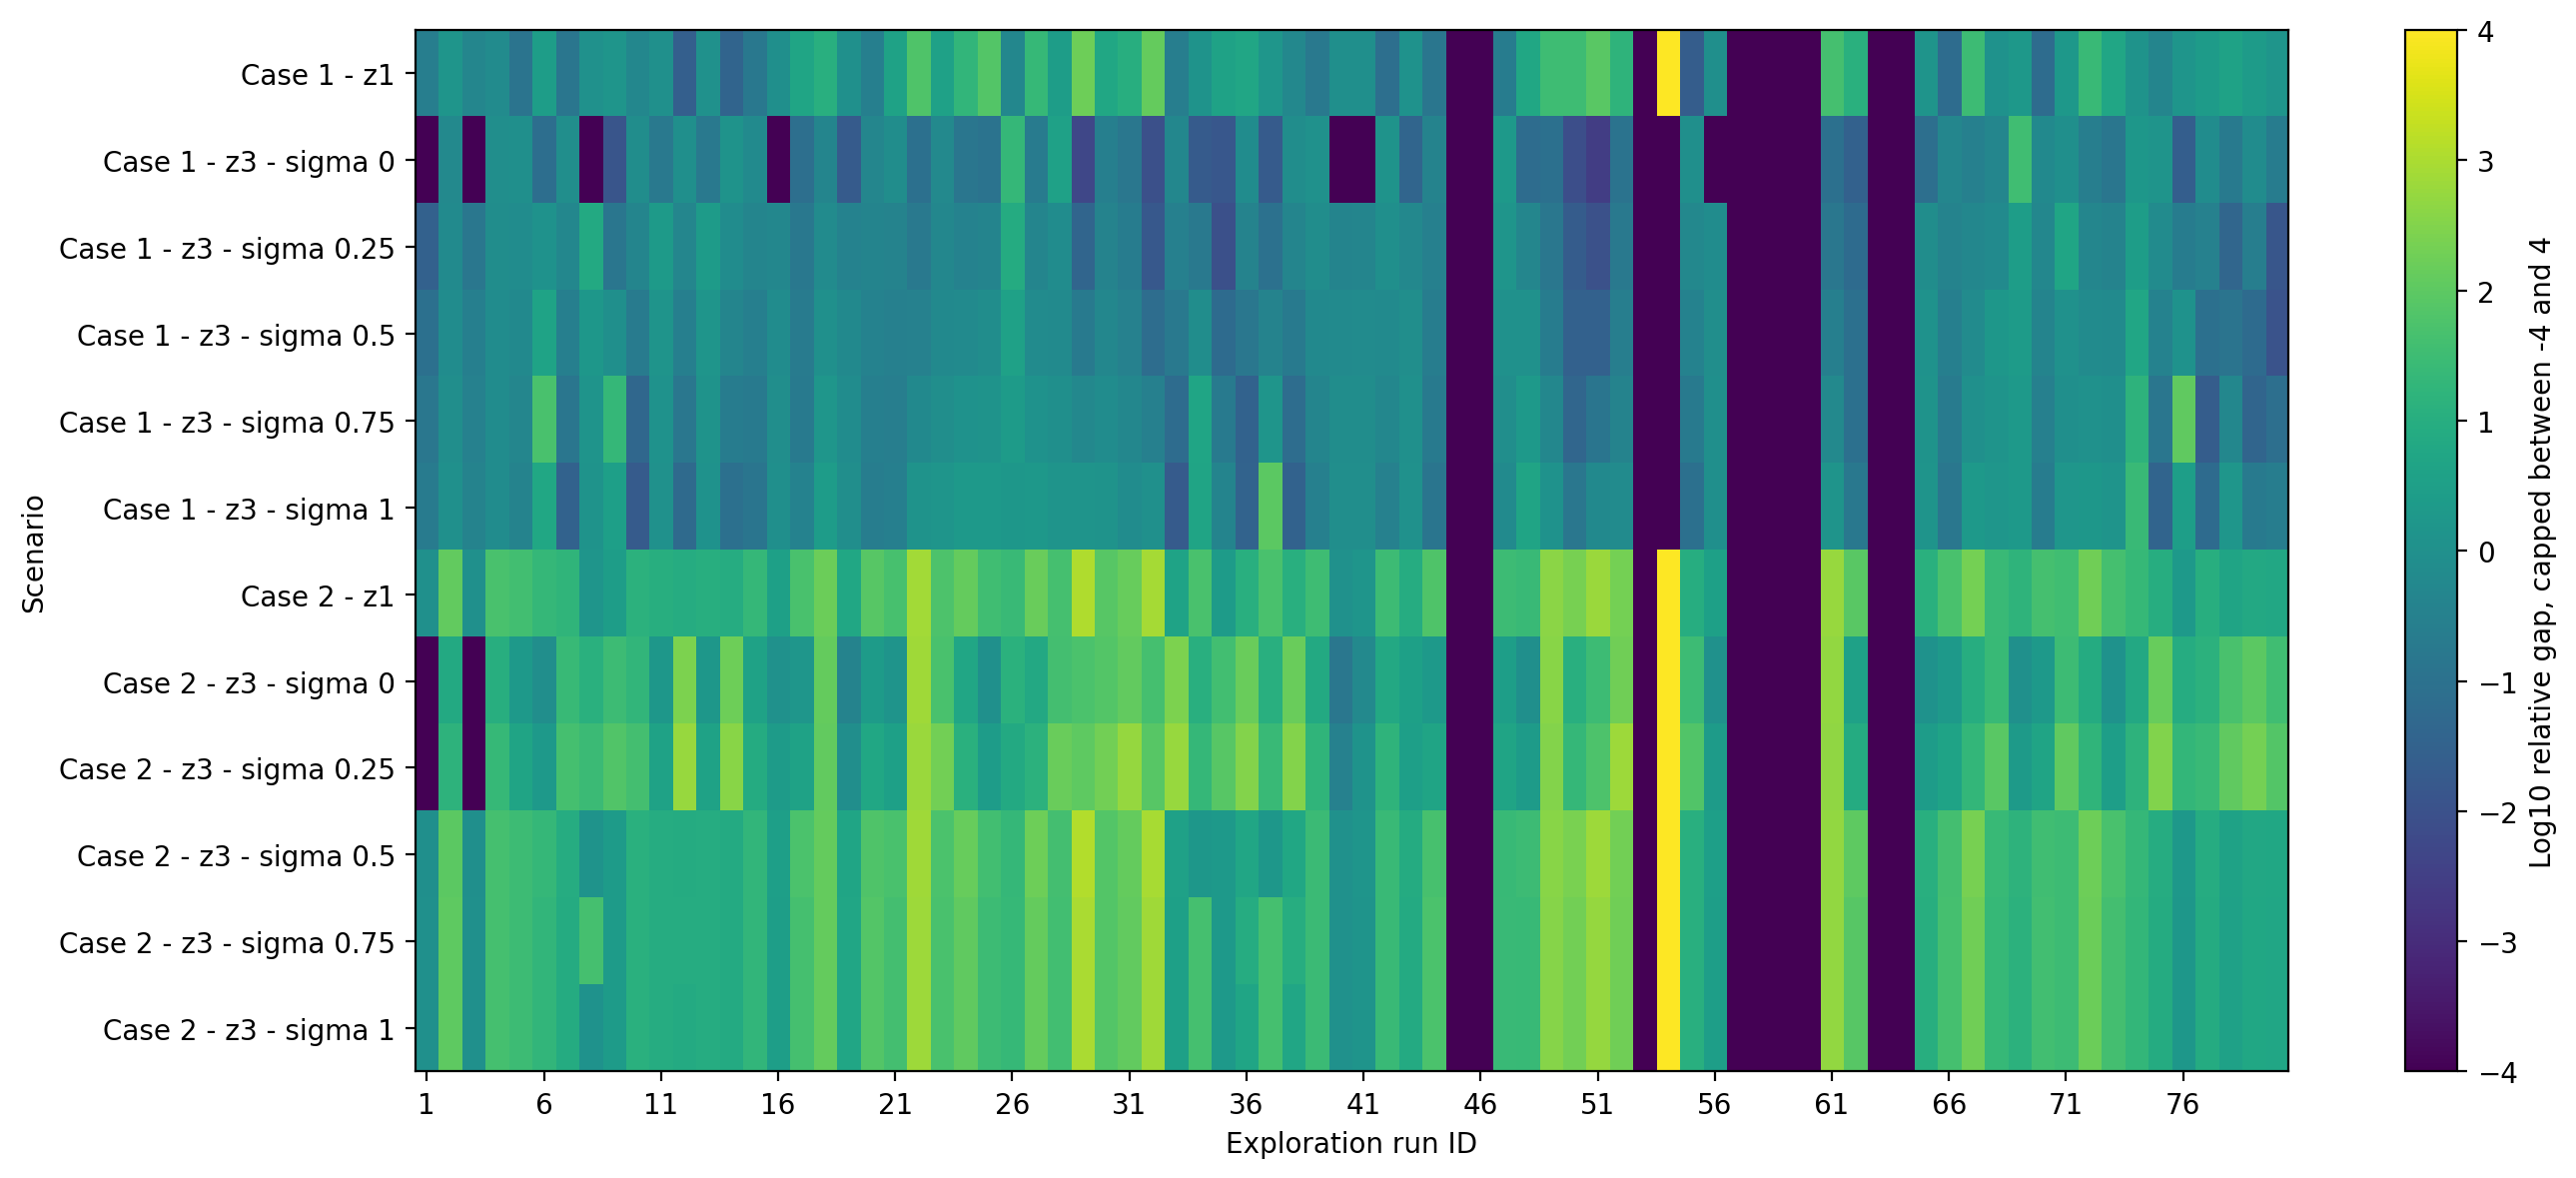

In [15]:
scenario_order = [
    (1, "z1", 0.00),
    (1, "z3", 0.00),
    (1, "z3", 0.25),
    (1, "z3", 0.50),
    (1, "z3", 0.75),
    (1, "z3", 1.00),
    (2, "z1", 0.00),
    (2, "z3", 0.00),
    (2, "z3", 0.25),
    (2, "z3", 0.50),
    (2, "z3", 0.75),
    (2, "z3", 1.00)
]

scenario_labels = []
heatmap_rows = []

for case_study, design, sigma in scenario_order:
    scenario_data = final_runs[
        (final_runs["case_study"] == case_study)
        & (final_runs["design"] == design)
        & (final_runs["sigma"] == sigma)
    ].sort_values("run_id")

    if len(scenario_data) == 0:
        continue

    gap_values = scenario_data["finite_gap"].to_numpy(dtype=float)
    gap_values = np.where(np.isnan(gap_values), 10000, gap_values)
    gap_values = np.clip(gap_values, 0.0001, 10000)

    heatmap_rows.append(np.log10(gap_values))

    if design == "z1":
        scenario_labels.append(f"Case {case_study} - z1")
    else:
        scenario_labels.append(
            f"Case {case_study} - z3 - sigma {sigma:g}"
        )

heatmap_data = np.vstack(heatmap_rows)

fig, ax = plt.subplots(figsize=(14, 6), dpi=200)

image = ax.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xlabel("Exploration run ID")
ax.set_ylabel("Scenario")

ax.set_xticks(np.arange(0, 80, 5))
ax.set_xticklabels(np.arange(1, 81, 5))

ax.set_yticks(np.arange(len(scenario_labels)))
ax.set_yticklabels(scenario_labels)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Log10 relative gap, capped between -4 and 4")

fig.tight_layout()
plt.show()


In [ ]:
output_folder = results_folder / "computational_performance"
output_folder.mkdir(exist_ok=True)

final_runs.to_csv(
    output_folder / "final_runs.csv",
    index=False
)

performance_summary.to_csv(
    output_folder / "performance_summary.csv",
    index=False
)

density_summary.to_csv(
    output_folder / "ptdf_density_summary.csv",
    index=False
)

recurring_difficult_runs.to_csv(
    output_folder / "recurring_difficult_runs.csv",
    index=False
)

fig.savefig(
    output_folder / "gap_heatmap.png",
    bbox_inches="tight"
)

print("Outputs saved in:", output_folder)


Outputs saved in: c:\Users\Alex\MasterThesis\results\computational_performance


: 